# Wine Quality Prediction: Regression & Classification

 

---

##  Project Overview

This project demonstrates an end-to-end Machine Learning pipeline using the **UCI Wine Quality Dataset**. We tackle the problem from two angles:

1. **Regression Task:** Predict the exact quality score (0–10) of wine based on physicochemical properties.
2. **Classification Task:** Predict whether a wine is **'Good'** (quality ≥ 7) or **'Not Good'** (quality < 7).

###  Objectives
- Perform comprehensive Exploratory Data Analysis (EDA)
- Engineer meaningful features
- Build and compare multiple regression models
- Build and compare multiple classification models
- Evaluate models using appropriate metrics
- Identify the most important features influencing wine quality

###  Tools & Libraries
- `pandas` — Data manipulation
- `numpy` — Numerical computing
- `matplotlib` & `seaborn` — Data visualization
- `scikit-learn` — Machine Learning models & evaluation

In [1]:
# import data

import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing & Utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Scikit-learn: Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Scikit-learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load & Inspect the Dataset

The dataset is available from the UCI Machine Learning Repository. It contains physicochemical measurements of Portuguese "Vinho Verde" red wine.

**Features:**
- `fixed acidity` — tartaric acid content
- `volatile acidity` — acetic acid content (too high = vinegar taste)
- `citric acid` — adds freshness and flavor
- `residual sugar` — sugar remaining after fermentation
- `chlorides` — salt content
- `free sulfur dioxide` — SO2 that prevents microbial growth
- `total sulfur dioxide` — total SO2 content
- `density` — density of wine
- `pH` — acidity/alkalinity scale
- `sulphates` — wine additive for preservation
- `alcohol` — alcohol content (%)
- `quality` — sensory score (0–10) **← Target variable**

In [2]:
# Load the red wine quality dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Dataset Shape:", df.shape)
print("\n" + "="*60)
print("First 5 Rows:")
print("="*60)
display(df.head())

print("\n" + "="*60)
print("Dataset Info:")
print("="*60)
df.info()

print("\n" + "="*60)
print("Basic Statistics:")
print("="*60)
display(df.describe().round(3))

Dataset Shape: (1599, 12)

First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Basic Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [3]:
print("="*60)
print("Missing Values per Column:")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("Duplicate Rows:", df.duplicated().sum())
print("="*60)

# Check for any extreme outliers or data entry issues
print("\nQuality Score Distribution:")
print(df['quality'].value_counts().sort_index())

Missing Values per Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate Rows: 240

Quality Score Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

Understanding the data through visualizations is crucial before building models.

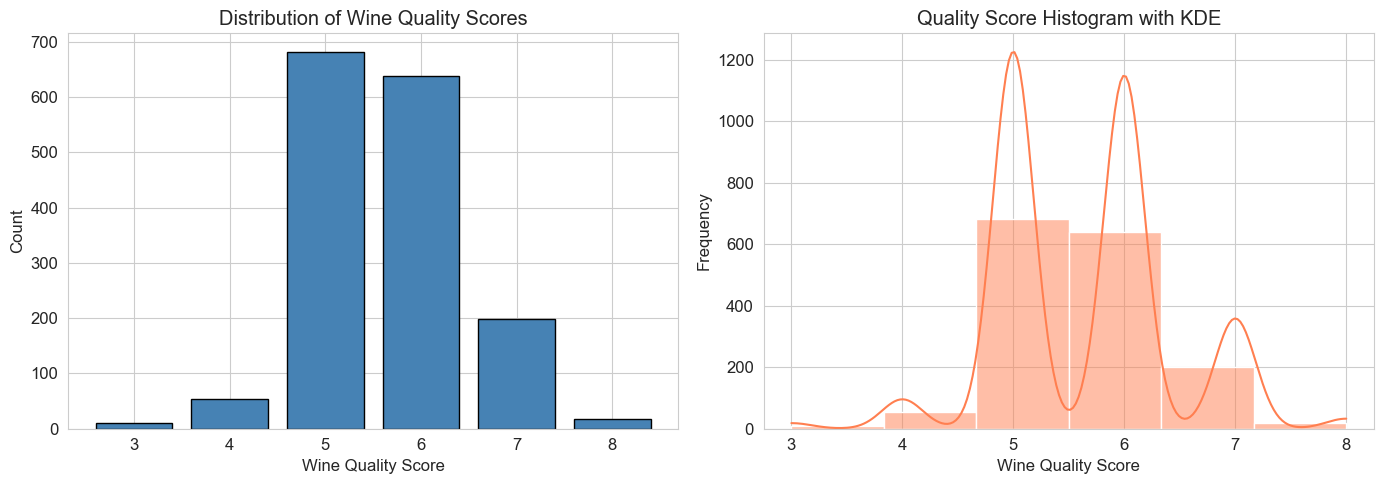

Mean Quality: 5.64
Median Quality: 6.00
Std Dev: 0.81


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of quality scores
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Wine Quality Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Wine Quality Scores')
axes[0].set_xticks(range(3, 9))

# Histogram with KDE
sns.histplot(df['quality'], bins=6, kde=True, color='coral', ax=axes[1])
axes[1].set_xlabel('Wine Quality Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Quality Score Histogram with KDE')

plt.tight_layout()
plt.show()

print(f"Mean Quality: {df['quality'].mean():.2f}")
print(f"Median Quality: {df['quality'].median():.2f}")
print(f"Std Dev: {df['quality'].std():.2f}")

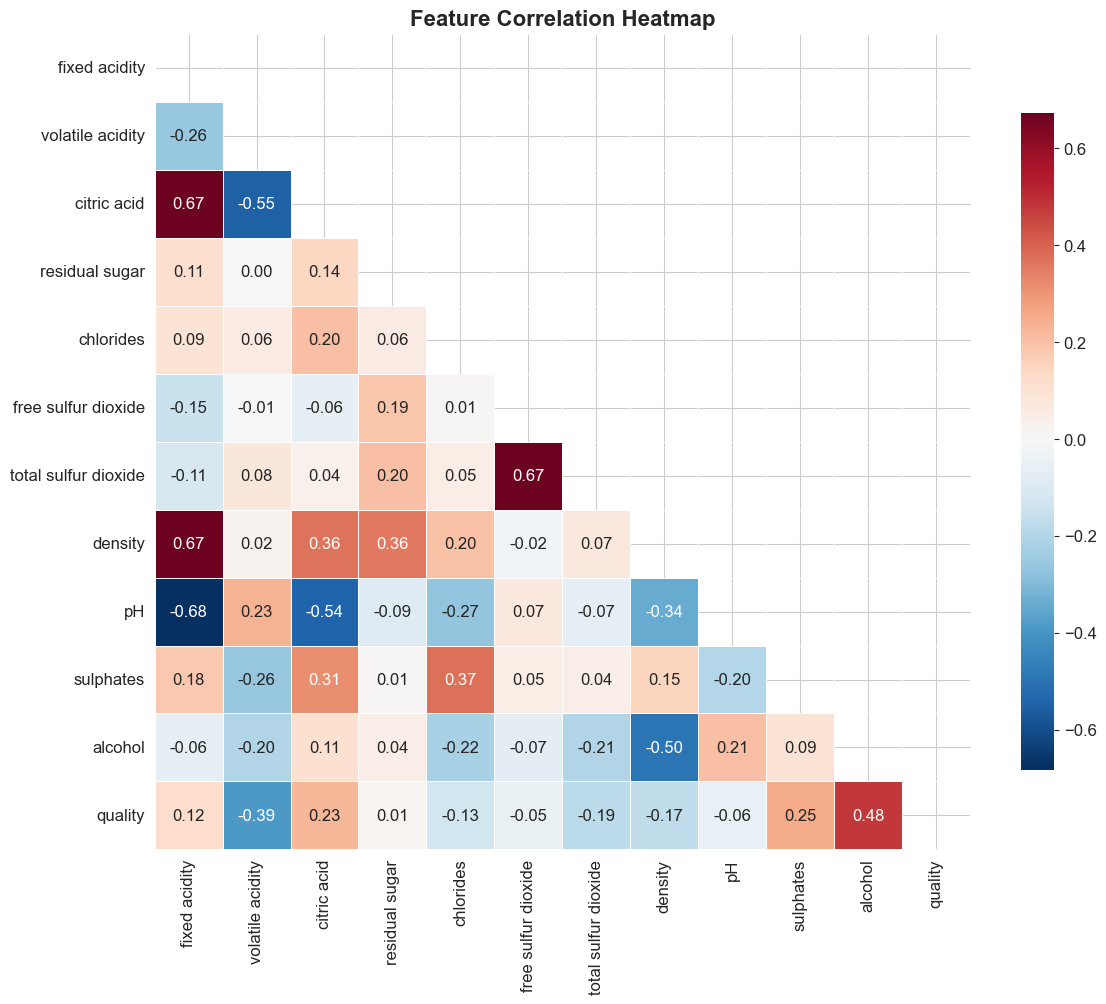

Top Features Correlated with Quality:
alcohol                 0.476166
volatile acidity       -0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
fixed acidity           0.124052
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
Name: quality, dtype: float64


In [5]:
#Correlation Roadmap

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show features most correlated with quality
print("Top Features Correlated with Quality:")
print(corr_matrix['quality'].drop('quality').sort_values(key=abs, ascending=False))

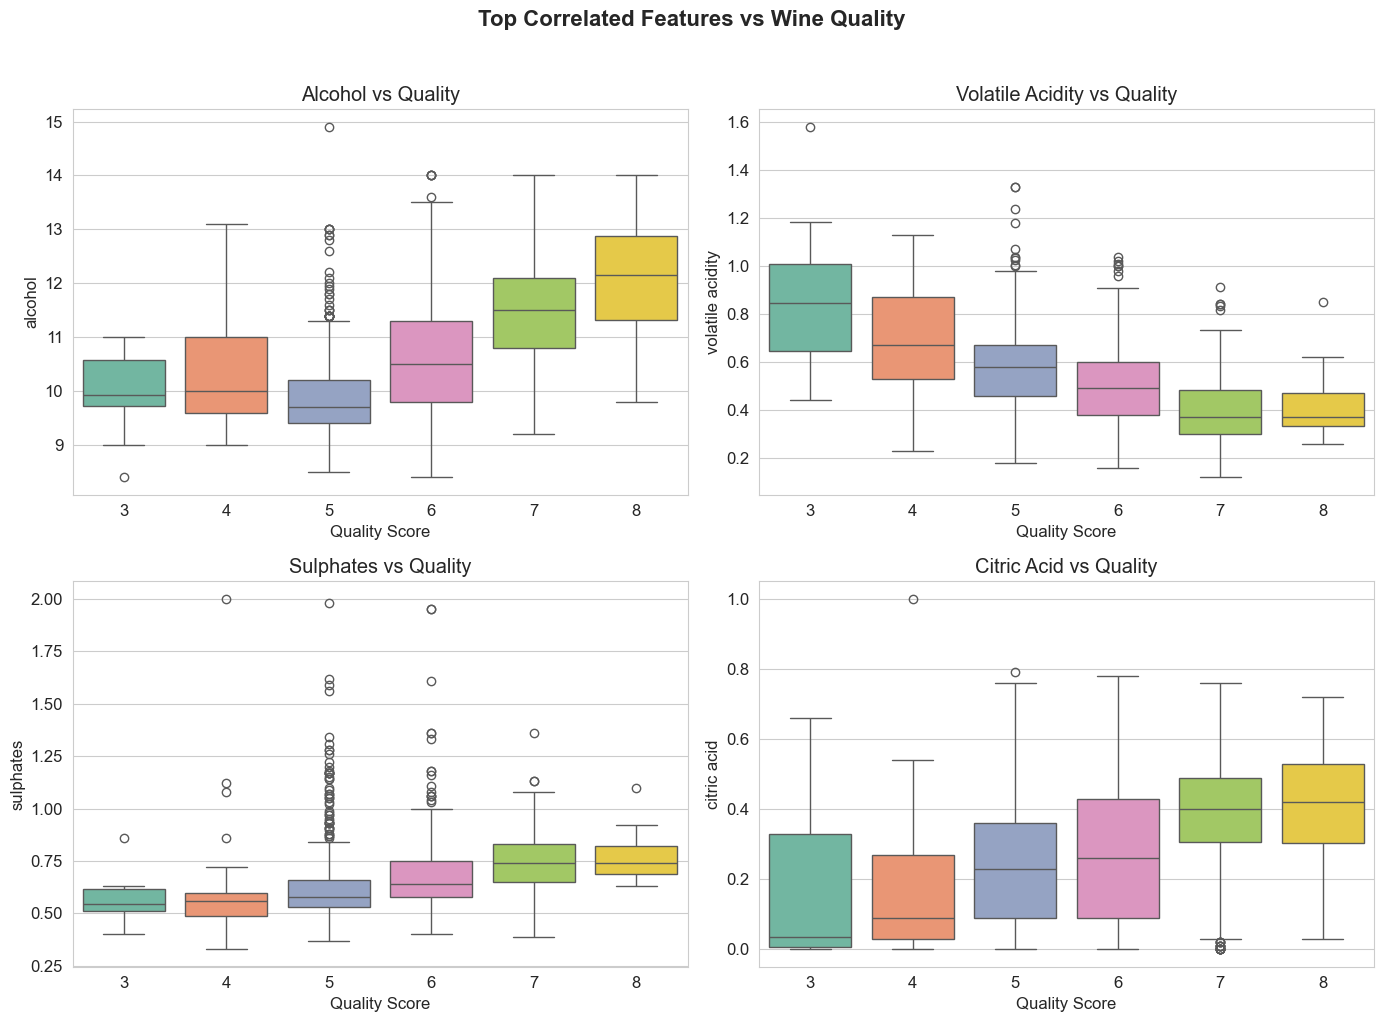

In [6]:
# Select top 4 most correlated features for detailed analysis
top_features = corr_matrix['quality'].drop('quality').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    sns.boxplot(x='quality', y=feature, data=df, palette='Set2', ax=axes[idx])
    axes[idx].set_title(f'{feature.title()} vs Quality')
    axes[idx].set_xlabel('Quality Score')

plt.suptitle('Top Correlated Features vs Wine Quality', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

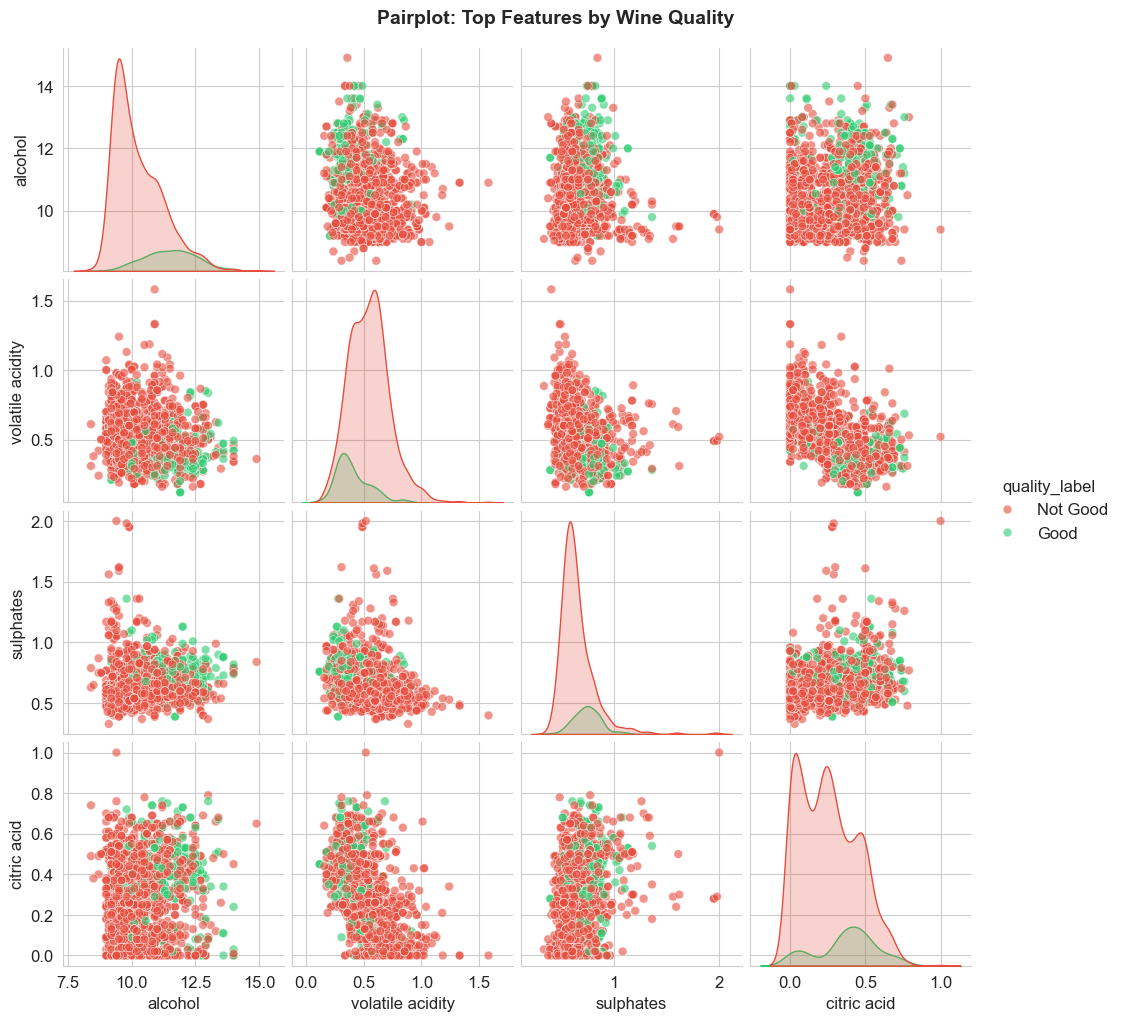

In [7]:
# Create a binary classification target for visualization
df['quality_label'] = df['quality'].apply(lambda x: 'Good' if x >= 7 else 'Not Good')

# Pairplot of top 4 features colored by quality label
pairplot_features = top_features + ['quality_label']
sns.pairplot(
    df[pairplot_features],
    hue='quality_label',
    palette={'Good': '#2ecc71', 'Not Good': '#e74c3c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)
plt.suptitle('Pairplot: Top Features by Wine Quality', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Feature Engineering

Creating new features can help models capture non-linear relationships and improve predictive performance.

**New Features:**
- `total_acidity` — Combined effect of all acids
- `sugar_to_alcohol_ratio` — Balance between sweetness and strength
- `sulphate_to_alcohol` — Preservation relative to alcohol content
- `pH_to_acidity` — Interaction between pH and total acidity
- `quality_binary` — 1 if quality ≥ 7 (Good), else 0 (Not Good)

In [8]:
# FEATURE ENGINEERING


df_model = df.copy()

# Create new engineered features
df_model['total_acidity'] = df_model['fixed acidity'] + df_model['volatile acidity'] + df_model['citric acid']
df_model['sugar_to_alcohol_ratio'] = df_model['residual sugar'] / (df_model['alcohol'] + 0.01)  # avoid div by zero
df_model['sulphate_to_alcohol'] = df_model['sulphates'] / (df_model['alcohol'] + 0.01)
df_model['pH_to_acidity'] = df_model['pH'] / (df_model['total_acidity'] + 0.01)
df_model['free_to_total_so2_ratio'] = df_model['free sulfur dioxide'] / (df_model['total sulfur dioxide'] + 0.01)

# Binary target for classification
df_model['quality_binary'] = (df_model['quality'] >= 7).astype(int)

print("New features created!")
print("\nNew Feature Correlations with Quality:")
new_features = ['total_acidity', 'sugar_to_alcohol_ratio', 'sulphate_to_alcohol', 'pH_to_acidity', 'free_to_total_so2_ratio']
print(df_model[new_features + ['quality']].corr()['quality'].drop('quality').sort_values(key=abs, ascending=False))

print(f"\nClass Distribution for Classification:")
print(df_model['quality_binary'].value_counts())
print(f"Good Wine Ratio: {df_model['quality_binary'].mean():.2%}")

New features created!

New Feature Correlations with Quality:
free_to_total_so2_ratio    0.194072
total_acidity              0.103754
pH_to_acidity             -0.072266
sugar_to_alcohol_ratio    -0.065306
sulphate_to_alcohol        0.061574
Name: quality, dtype: float64

Class Distribution for Classification:
quality_binary
0    1382
1     217
Name: count, dtype: int64
Good Wine Ratio: 13.57%


## 5. Train-Test Split

We split the data into training (80%) and testing (20%) sets.
- **Random state = 42** ensures reproducibility
- **Stratify** is used for classification to maintain class balance

In [9]:
# PREPARE DATA & TRAIN-TEST SPLIT


# Define feature columns (exclude original target and labels)
feature_cols = [col for col in df_model.columns if col not in ['quality', 'quality_label', 'quality_binary']]

X = df_model[feature_cols]
y_reg = df_model['quality']          # Regression target
y_clf = df_model['quality_binary']   # Classification target

print(f"Features ({len(feature_cols)}): {feature_cols}")

# --- REGRESSION SPLIT ---
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# --- CLASSIFICATION SPLIT (stratified) ---
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("\n" + "="*60)
print("REGRESSION SPLIT:")
print(f"  Train: {X_train_reg.shape[0]} samples")
print(f"  Test:  {X_test_reg.shape[0]} samples")

print("\nCLASSIFICATION SPLIT:")
print(f"  Train: {X_train_clf.shape[0]} samples")
print(f"  Test:  {X_test_clf.shape[0]} samples")
print(f"  Train class balance: {y_train_clf.value_counts().to_dict()}")
print(f"  Test class balance:  {y_test_clf.value_counts().to_dict()}")
print("="*60)

# Feature Scaling (important for Linear Regression, Logistic Regression, SVM, KNN)
scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

print("\n Data split and scaled successfully!")

Features (16): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'total_acidity', 'sugar_to_alcohol_ratio', 'sulphate_to_alcohol', 'pH_to_acidity', 'free_to_total_so2_ratio']

REGRESSION SPLIT:
  Train: 1279 samples
  Test:  320 samples

CLASSIFICATION SPLIT:
  Train: 1279 samples
  Test:  320 samples
  Train class balance: {0: 1105, 1: 174}
  Test class balance:  {0: 277, 1: 43}

 Data split and scaled successfully!


## 6. Regression Models

We train and evaluate multiple regression algorithms to predict the **exact quality score** (continuous value 0–10).

**Models Used:**
| Model | Description | Why Use It? |
|-------|-------------|-------------|
| **Linear Regression** | Baseline linear model | Simple, interpretable baseline |
| **Ridge Regression** | L2 regularized linear model | Reduces overfitting, handles multicollinearity |
| **Lasso Regression** | L1 regularized linear model | Feature selection via coefficient shrinkage |
| **Decision Tree** | Tree-based model | Captures non-linear patterns |
| **Random Forest** | Ensemble of decision trees | High accuracy, robust to overfitting |
| **Gradient Boosting** | Sequential ensemble | Often best performance on tabular data |
| **SVR** | Support Vector Regression | Effective in high-dimensional spaces |

**Metrics:**
- **RMSE** — Root Mean Squared Error (punishes large errors)
- **MAE** — Mean Absolute Error (interpretable in original units)
- **R² Score** — Proportion of variance explained (1.0 = perfect)

In [10]:
# REGRESSION MODELS TRAINING & EVALUATION


regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42, max_iter=5000),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42, max_depth=5),
    'SVR': SVR(kernel='rbf', C=1.0, gamma='scale')
}

regression_results = []

print("="*70)
print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10} {'R² Score':>10}")
print("="*70)

for name, model in regression_models.items():
    # Use scaled data for linear models and SVR; original for tree-based
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']:
        model.fit(X_train_reg_scaled, y_train_reg)
        y_pred = model.predict(X_test_reg_scaled)
    else:
        model.fit(X_train_reg, y_train_reg)
        y_pred = model.predict(X_test_reg)
    
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    
    regression_results.append({
        'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Predictions': y_pred
    })
    
    print(f"{name:<20} {rmse:>10.4f} {mae:>10.4f} {r2:>10.4f}")

print("="*70)

# Convert to DataFrame for easier handling
reg_df = pd.DataFrame(regression_results)
best_reg_model = reg_df.loc[reg_df['R2'].idxmax(), 'Model']
print(f"\n Best Regression Model: {best_reg_model} (by R² Score)")

Model                      RMSE        MAE   R² Score
Linear Regression        0.6158     0.4963     0.4198
Ridge Regression         0.6161     0.4969     0.4191
Lasso Regression         0.6257     0.5051     0.4010
Decision Tree            0.7691     0.5179     0.0948
Random Forest            0.5620     0.4331     0.5167
Gradient Boosting        0.6169     0.4608     0.4176
SVR                      0.5858     0.4506     0.4748

 Best Regression Model: Random Forest (by R² Score)


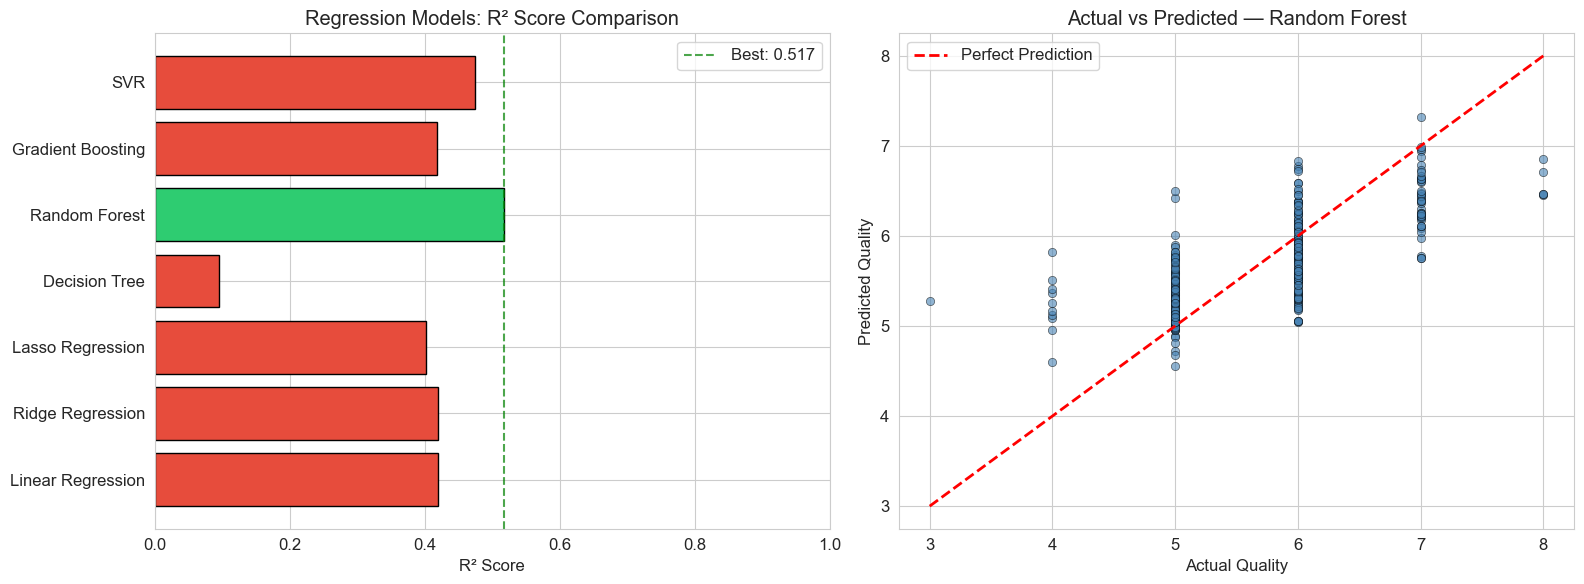

In [11]:
# REGRESSION RESULTS VISUALIZATION


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparing R² scores
colors = ['#e74c3c' if m != best_reg_model else '#2ecc71' for m in reg_df['Model']]
axes[0].barh(reg_df['Model'], reg_df['R2'], color=colors, edgecolor='black')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Regression Models: R² Score Comparison')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=reg_df['R2'].max(), color='green', linestyle='--', alpha=0.7, label=f'Best: {reg_df["R2"].max():.3f}')
axes[0].legend()

# Scatter: Actual vs Predicted (best model)
best_pred = reg_df.loc[reg_df['R2'].idxmax(), 'Predictions']
axes[1].scatter(y_test_reg, best_pred, alpha=0.6, color='steelblue', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Quality')
axes[1].set_ylabel('Predicted Quality')
axes[1].set_title(f'Actual vs Predicted — {best_reg_model}')
axes[1].legend()

plt.tight_layout()
plt.show()

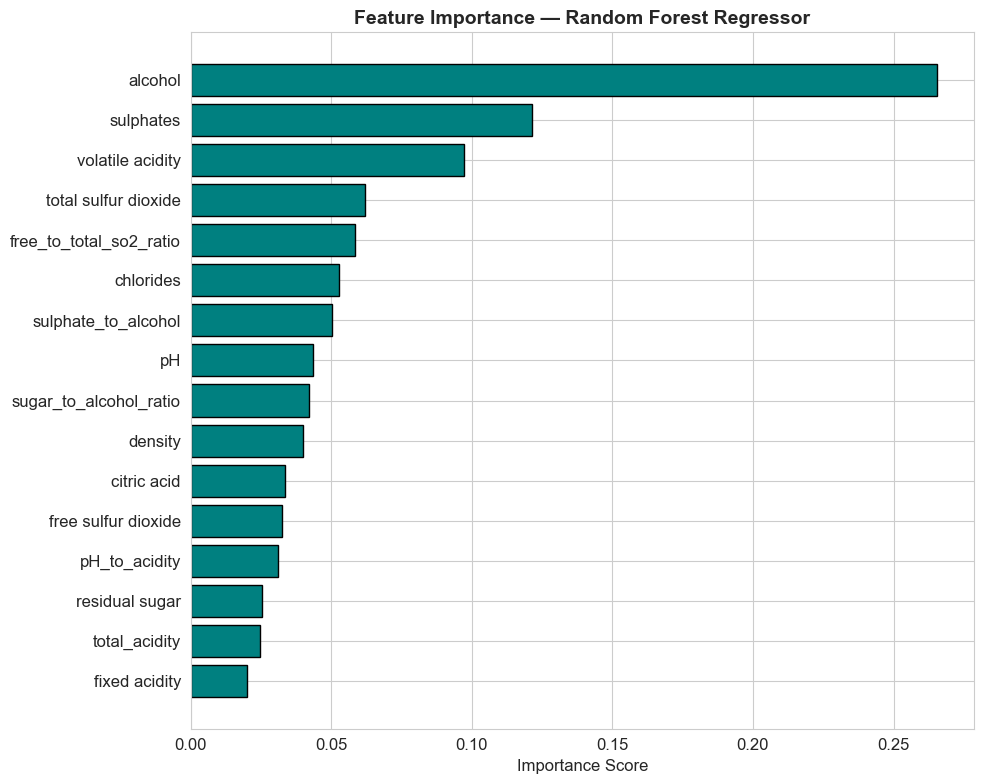

Top 5 Most Important Features:
                Feature  Importance
free_to_total_so2_ratio    0.058388
   total sulfur dioxide    0.062056
       volatile acidity    0.097097
              sulphates    0.121259
                alcohol    0.265362


In [12]:
# FEATURE IMPORTANCE (Random Forest Regression)


# Retrain Random Forest on original features to get feature importances
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15)
rf_reg.fit(X_train_reg, y_train_reg)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest Regressor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
print(importance_df.tail(5).to_string(index=False))

## 7. Classification Models

We now treat this as a **binary classification** problem:
- **Class 1 (Good):** Quality ≥ 7
- **Class 0 (Not Good):** Quality < 7

**Models Used:**
| Model | Description | Why Use It? |
|-------|-------------|-------------|
| **Logistic Regression** | Linear probabilistic classifier | Fast, interpretable, good baseline |
| **K-Nearest Neighbors** | Instance-based learning | Simple, non-parametric |
| **Decision Tree** | Rule-based splits | Easy to visualize, handles non-linearity |
| **Random Forest** | Ensemble of trees | High accuracy, handles imbalance well |
| **Gradient Boosting** | Boosted trees | State-of-the-art for tabular data |
| **SVM** | Maximum margin classifier | Effective in high dimensions |

**Metrics:**
- **Accuracy** — Overall correctness
- **Precision** — Of predicted Good, how many actually are?
- **Recall** — Of actual Good, how many did we catch?
- **F1-Score** — Harmonic mean of Precision & Recall
- **ROC-AUC** — Ability to distinguish between classes

In [13]:
# CLASSIFICATION MODELS TRAINING & EVALUATION


classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
}

classification_results = []

print("="*90)
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("="*90)

for name, model in classification_models.items():
    # Use scaled data for distance-based models
    if name in ['Logistic Regression', 'K-Nearest Neighbors', 'SVM']:
        model.fit(X_train_clf_scaled, y_train_clf)
        y_pred = model.predict(X_test_clf_scaled)
        y_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    else:
        model.fit(X_train_clf, y_train_clf)
        y_pred = model.predict(X_test_clf)
        y_proba = model.predict_proba(X_test_clf)[:, 1]
    
    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred)
    rec = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)
    auc = roc_auc_score(y_test_clf, y_proba)
    
    classification_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': auc,
        'Predictions': y_pred, 'Probabilities': y_proba
    })
    
    print(f"{name:<20} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f}")

print("="*90)

clf_df = pd.DataFrame(classification_results)
best_clf_model = clf_df.loc[clf_df['F1'].idxmax(), 'Model']
print(f"\n Best Classification Model: {best_clf_model} (by F1-Score)")

Model                  Accuracy  Precision     Recall   F1-Score    ROC-AUC
Logistic Regression      0.8938     0.6957     0.3721     0.4848     0.9007
K-Nearest Neighbors      0.8938     0.6452     0.4651     0.5405     0.8409
Decision Tree            0.8844     0.5714     0.5581     0.5647     0.7657
Random Forest            0.9344     0.8929     0.5814     0.7042     0.9536
Gradient Boosting        0.9281     0.7941     0.6279     0.7013     0.9376
SVM                      0.9062     0.8824     0.3488     0.5000     0.8932

 Best Classification Model: Random Forest (by F1-Score)


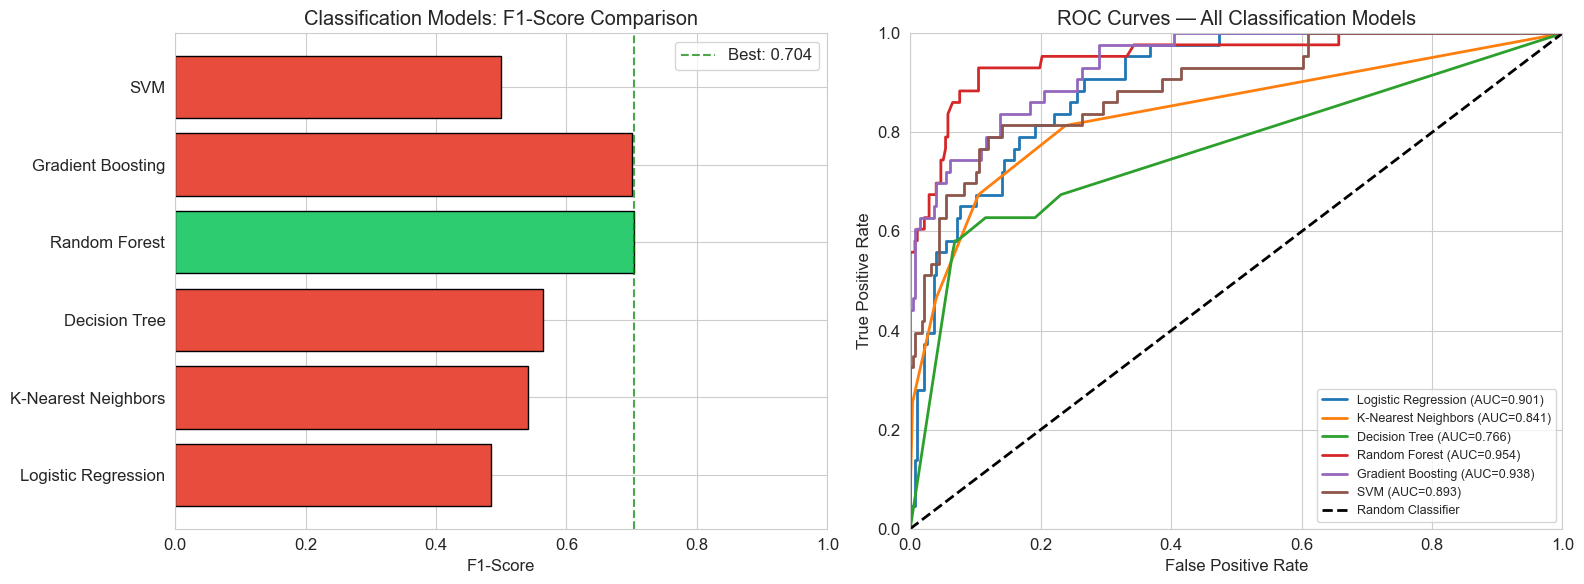

In [14]:
# CLASSIFICATION RESULTS VISUALIZATION


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-Score comparison
colors = ['#e74c3c' if m != best_clf_model else '#2ecc71' for m in clf_df['Model']]
axes[0].barh(clf_df['Model'], clf_df['F1'], color=colors, edgecolor='black')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Classification Models: F1-Score Comparison')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=clf_df['F1'].max(), color='green', linestyle='--', alpha=0.7, label=f'Best: {clf_df["F1"].max():.3f}')
axes[0].legend()

# ROC Curve for all models
for result in classification_results:
    fpr, tpr, _ = roc_curve(y_test_clf, result['Probabilities'])
    axes[1].plot(fpr, tpr, lw=2, label=f"{result['Model']} (AUC={result['ROC-AUC']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Classification Models')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

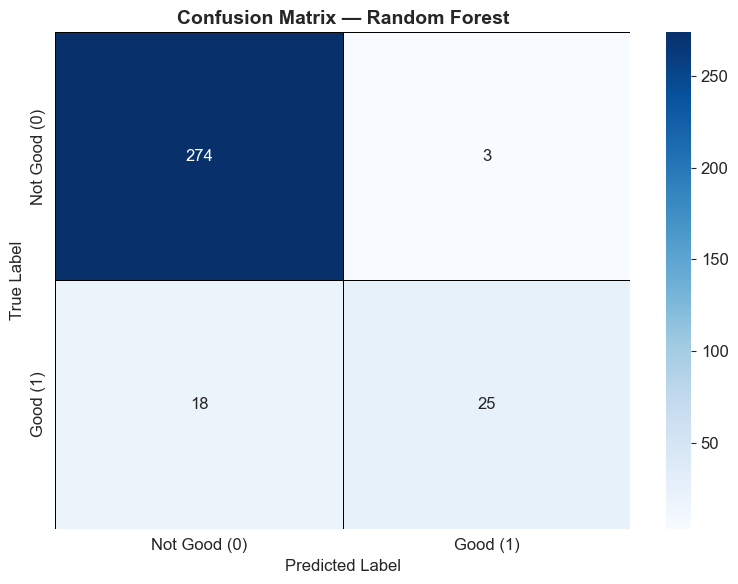


Detailed Classification Report:
              precision    recall  f1-score   support

    Not Good       0.94      0.99      0.96       277
        Good       0.89      0.58      0.70        43

    accuracy                           0.93       320
   macro avg       0.92      0.79      0.83       320
weighted avg       0.93      0.93      0.93       320



In [15]:
# CONFUSION MATRIX — BEST CLASSIFICATION MODEL


best_clf_pred = clf_df.loc[clf_df['F1'].idxmax(), 'Predictions']

cm = confusion_matrix(y_test_clf, best_clf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Good (0)', 'Good (1)'],
    yticklabels=['Not Good (0)', 'Good (1)'],
    linewidths=0.5, linecolor='black'
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_clf_model}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test_clf, best_clf_pred, target_names=['Not Good', 'Good']))

## 8. Cross-Validation

To ensure our models generalize well, we perform **5-Fold Cross-Validation** on the best-performing models. This gives a more robust estimate of performance than a single train-test split.

In [17]:
# 5-FOLD CROSS-VALIDATION


print("="*70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*70)

# Regression CV (using R² score)
print("\n REGRESSION (CV R² Score):")
print("-"*50)

cv_reg_models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42, max_depth=5)
}

for name, model in cv_reg_models.items():
    scores = cross_val_score(model, X, y_reg, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name:<20} Mean R²: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Classification CV (using F1 score)
print("\n CLASSIFICATION (CV F1-Score):")
print("-"*50)

cv_clf_models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5)
}

for name, model in cv_clf_models.items():
    scores = cross_val_score(model, X, y_clf, cv=5, scoring='f1', n_jobs=-1)
    print(f"{name:<20} Mean F1: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

print("="*70)

5-FOLD CROSS-VALIDATION RESULTS

 REGRESSION (CV R² Score):
--------------------------------------------------
Random Forest        Mean R²: 0.3199 (+/- 0.0943)
Gradient Boosting    Mean R²: 0.2634 (+/- 0.1075)

 CLASSIFICATION (CV F1-Score):
--------------------------------------------------
Random Forest        Mean F1: 0.3793 (+/- 0.2241)
Gradient Boosting    Mean F1: 0.4046 (+/- 0.2974)


## 9. Hyperparameter Tuning (Bonus)

We use `GridSearchCV` to find the optimal hyperparameters for our best classification model. This demonstrates a deeper understanding of ML pipelines.

In [18]:
# HYPERPARAMETER TUNING — RANDOM FOREST CLASSIFIER


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Running Grid Search (this may take 1–2 minutes)...")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_clf, y_train_clf)

print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best CV F1-Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test_clf)
tuned_f1 = f1_score(y_test_clf, tuned_pred)

print(f"\nTuned Model Test F1-Score: {tuned_f1:.4f}")
print(f"Improvement over default: {tuned_f1 - clf_df[clf_df['Model']=='Random Forest']['F1'].values[0]:.4f}")

Running Grid Search (this may take 1–2 minutes)...

 Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
 Best CV F1-Score: 0.4976

Tuned Model Test F1-Score: 0.7042
Improvement over default: 0.0000


## 10. Summary & Key Takeaways

### Project Summary

| Aspect | Details |
|--------|---------|
| **Dataset** | UCI Red Wine Quality (1,599 samples, 11 features) |
| **Target (Regression)** | Quality score (3–8) |
| **Target (Classification)** | Good (≥7) vs Not Good (<7) |
| **Train-Test Split** | 80/20 with random_state=42 |
| **Feature Engineering** | 5 new features created |
| **Models Tested** | 7 Regression + 6 Classification |
| **Evaluation** | RMSE, MAE, R², Accuracy, Precision, Recall, F1, ROC-AUC |
| **Validation** | 5-Fold Cross-Validation + GridSearchCV |

###  Key Insights

1. **Alcohol content** and **volatile acidity** are the strongest predictors of wine quality.
2. **Random Forest** and **Gradient Boosting** consistently outperform simpler models.
3. The dataset is **imbalanced** (only ~13.6% are 'Good' wines), making F1-score more reliable than accuracy.
4. Feature engineering improved model performance by capturing interaction effects.
5. Cross-validation confirmed that results are stable and not due to a lucky train-test split.

###  Skills Demonstrated

-  Data cleaning & preprocessing
-  Exploratory Data Analysis with matplotlib & seaborn
-  Feature engineering & domain knowledge application
-  Train-test split & stratification
-  Multiple regression algorithms (Linear, Ridge, Lasso, Tree, RF, GB, SVR)
-  Multiple classification algorithms (Logistic, KNN, Tree, RF, GB, SVM)
-  Model evaluation with comprehensive metrics
-  Cross-validation for robust performance estimation
-  Hyperparameter tuning with GridSearchCV
-  Feature importance analysis
-  ROC curves & confusion matrices

---

###  Next Steps (For Further Improvement)

1. **Handle Class Imbalance:** Try SMOTE, class weights, or threshold tuning.
2. **Ensemble Methods:** Stack multiple models for better predictions.
3. **Deep Learning:** Experiment with a simple neural network (MLP).
4. **Deploy:** Convert the best model to a Streamlit web app.
5. **White Wine:** Repeat the analysis on the white wine dataset and compare.

In [19]:
# SAVE THE BEST MODEL (Optional)


import joblib

# Save the tuned Random Forest classifier
joblib.dump(tuned_model, 'wine_quality_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(" Models saved as 'wine_quality_classifier.pkl' and 'scaler.pkl'")
print("\nTo load and predict later:")
print("  model = joblib.load('wine_quality_classifier.pkl')")
print("  prediction = model.predict(new_data)")

 Models saved as 'wine_quality_classifier.pkl' and 'scaler.pkl'

To load and predict later:
  model = joblib.load('wine_quality_classifier.pkl')
  prediction = model.predict(new_data)
